# Feature Engineering, Clustering, Experimentos A/B y Optimización de Hiperparámetros

El Sprint 1 identificó la mejor estrategia de balanceo para cada modelo (pesos de clase para CatBoost, sobremuestreo para los demás) y descartó PCA. El ganador fue **CatBoost** con F2\_CV = 0.6678. En este sprint se busca **enriquecer el espacio de features** con información geoquímica derivada de la bibliografía epitermal y con un clustering litológico no supervisado.

Se abordan cuatro ejes:

1. **Feature Engineering epitermal con bibliografía:** índices de alteración (AI de Ishikawa, CCPI de Large, CIA molar), ratios sericíticos (K/Al, Na/Al) y ratios de zonación de pathfinders (As/Sb, Sb/Tl, Te/Se) — cada feature con su cita publicada. NO se generan ratios combinatorios genéricos (que diluyen la señal); cada nueva variable tiene justificación geológica.
2. **Clustering litológico (CLR + GMM):** transformación CLR (Aitchison 1986) sobre trazas inmóviles, seguida de GMM + selección por BIC. El cluster litológico se usa como feature + interacción "percentil de pathfinder dentro del cluster" para capturar anomalías relativas al tipo de roca.
3. **Experimentos A/B:** base / +índices epitermales / +cluster litológico / +índices+cluster+interacciones.
4. **Optuna 50 trials:** búsqueda bayesiana (TPE) con `class_weight`/`scale_pos_weight` en el espacio de búsqueda para todos los modelos que lo soporten.

**Criterio de decisión:** F2\_CV 5-fold estratificada (prioriza Recall). Hold-out informativo.
**Top-3:** el mejor de cada FAMILIA (para diversidad en el stacking del Sprint 4).

## Configuración

In [25]:
import warnings, os, json, time, platform, re
from datetime import datetime
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (fbeta_score, f1_score, accuracy_score, precision_score,
                             recall_score, roc_auc_score, average_precision_score,
                             confusion_matrix, precision_recall_curve, roc_curve, make_scorer)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

F2_SCORER = make_scorer(fbeta_score, beta=2)

OUT = 'outputs_sprint2'
DIR_DATA    = f'{OUT}/data'
DIR_MODELS  = f'{OUT}/models'
DIR_FIG     = f'{OUT}/figures'
DIR_TAB     = f'{OUT}/tables'
for d in (OUT, DIR_DATA, DIR_MODELS, DIR_FIG, DIR_TAB):
    os.makedirs(d, exist_ok=True)

MODEL_COLORS = {
    'KNN': 'blue', 'Reg. Logística': 'orange', 'SVM (RBF)': 'teal', 'MLP': 'magenta',
    'Árbol de Decisión': 'green', 'Random Forest': 'darkred', 'ExtraTrees': 'olive',
    'HistGradientBoosting': 'brown', 'XGBoost': 'purple', 'LightGBM': 'darkcyan', 'CatBoost': 'goldenrod',
}
MODELOS = list(MODEL_COLORS.keys())

def coral(texto):
    '''Resalta texto en color coral para resultados clave.'''
    return f'\033[38;2;255;127;80m{texto}\033[0m'

# ── Familias para el top-3 diverso ──
FAMILIAS = {
    'Boosting': ['HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost'],
    'Bagging/Árbol': ['Random Forest', 'ExtraTrees', 'Árbol de Decisión'],
    'Lineal/Kernel': ['Reg. Logística', 'SVM (RBF)'],
    'Red neuronal': ['MLP'],
    'Vecinos': ['KNN'],
}

print('Carpetas listas:', OUT)

Carpetas listas: outputs_sprint2


## Versiones de librerías

In [26]:
import sklearn, imblearn
versiones = {
    'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__, 'imbalanced-learn': imblearn.__version__,
    'xgboost': xgb.__version__, 'lightgbm': lgb.__version__,
    'optuna': optuna.__version__,
    'matplotlib': __import__('matplotlib').__version__, 'seaborn': sns.__version__,
    'joblib': joblib.__version__,
}
try:
    import catboost; versiones['catboost'] = catboost.__version__
except: pass
print('Versiones registradas:')
for k, v in versiones.items():
    print(f'  {k:18s}: {v}')

Versiones registradas:
  python            : 3.12.1
  numpy             : 2.4.6
  pandas            : 2.3.3
  scikit-learn      : 1.9.0
  imbalanced-learn  : 0.14.2
  xgboost           : 3.3.0
  lightgbm          : 4.6.0
  optuna            : 4.9.0
  matplotlib        : 3.11.0
  seaborn           : 0.13.2
  joblib            : 1.5.3
  catboost          : 1.2.10


## Carga de artefactos de sprints anteriores

Se cargan: dataset procesado del Sprint 0 (43 features no económicas, 4 grupos geoquímicos), índices del split, la estrategia de balanceo ganadora de cada modelo (Sprint 1) y los clasificadores base del Sprint 0 (hiperparámetros puros, sin pesos de clase). No se re-deriva el split.

In [27]:
# ── Cargar resúmenes ──
with open('outputs_sprint0/resumen_sprint0.json') as f:
    RESUMEN_S0 = json.load(f)
with open('outputs_sprint1/resumen_sprint1.json') as f:
    RESUMEN_S1 = json.load(f)

F2_SPRINT1    = RESUMEN_S1['f2_final']
FEATURES_BASE = RESUMEN_S0['features']
GRUPOS        = RESUMEN_S0['grupos_geoquimicos']
BAL_POR_MOD   = RESUMEN_S1['balanceo_por_modelo']

# ── Cargar dataset procesado ──
df = pd.read_csv('outputs_sprint0/data/data_procesada.csv')
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()

# ── Cargar índices del split ──
idx_train = np.load('outputs_sprint0/data/idx_train.npy')
idx_test  = np.load('outputs_sprint0/data/idx_test.npy')
X_train, X_test = X.loc[idx_train], X.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SPW = float((y_train == 0).sum() / (y_train == 1).sum())

# ── Cargar modelos base del Sprint 0 ──
_modelos_s0 = {}
for nombre, ruta in RESUMEN_S0['modelos_guardados'].items():
    _modelos_s0[nombre] = joblib.load(ruta)
print(f'{len(_modelos_s0)} modelos base cargados de outputs_sprint0/models/')

# ── Verificación ──
assert X_train.shape[1] == len(FEATURES_BASE)
assert len(X_train) + len(X_test) == len(df)

print(f'Modelos: {len(MODELOS)} | Features base: {len(FEATURES_BASE)}')
for g, cols in GRUPOS.items():
    print(f'  {g:35s}: {len(cols)} features')
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'scale_pos_weight = {SPW:.2f}')
print(coral(f'F2_CV ganador Sprint 1: {F2_SPRINT1:.4f} ({RESUMEN_S1["mejor_modelo"]}, {RESUMEN_S1["metodo_balanceo"]})'))

11 modelos base cargados de outputs_sprint0/models/
Modelos: 11 | Features base: 43
  Mayores (alteración)               : 10 features
  Trazas inmóviles (litología)       : 15 features
  Trazas móviles (pathfinders)       : 11 features
  LILE/álcalis (alteración compl.)   : 5 features
  Indicadores de detección           : 2 features
Train: (1705, 43) | Test: (427, 43)
scale_pos_weight = 7.20
F2_CV ganador Sprint 1: 0.6678 (CatBoost, Pesos de clase)


## Funciones

Los clasificadores base se obtienen clonando los del Sprint 0 (hiperparámetros puros). Con `pesos=True` se activa `class_weight='balanced'` o `scale_pos_weight` según el modelo. El balanceo por modelo viene del Sprint 1: puede ser un sobremuestreador (SMOTE, ADASYN, etc.) o "Pesos de clase".

In [28]:
SOPORTA_PESOS = {
    'Reg. Logística': dict(class_weight='balanced'),
    'SVM (RBF)': dict(class_weight='balanced'),
    'Árbol de Decisión': dict(class_weight='balanced'),
    'Random Forest': dict(class_weight='balanced'),
    'ExtraTrees': dict(class_weight='balanced'),
    'HistGradientBoosting': dict(class_weight='balanced'),
    'LightGBM': dict(class_weight='balanced'),
    'CatBoost': dict(auto_class_weights='Balanced'),
    'XGBoost': None,
}

def crear_clf(mod, pesos=False):
    '''Clona el clasificador base S0. Con pesos=True aplica class_weight/scale_pos_weight.'''
    clf = clone(_modelos_s0[mod].named_steps['clf'])
    if pesos:
        if mod == 'XGBoost':
            clf.set_params(scale_pos_weight=SPW)
        elif mod in SOPORTA_PESOS:
            clf.set_params(**SOPORTA_PESOS[mod])
    return clf

def crear_balanceador(nombre):
    if nombre in ('Sin balanceo', 'Pesos de clase'): return None
    if nombre == 'RandomOverSampler': return RandomOverSampler(random_state=SEED)
    if nombre == 'SMOTE':             return SMOTE(random_state=SEED, k_neighbors=5)
    if nombre == 'BorderlineSMOTE':   return BorderlineSMOTE(random_state=SEED, k_neighbors=5)
    if nombre == 'ADASYN':            return ADASYN(random_state=SEED)
    if nombre == 'SMOTETomek':        return SMOTETomek(random_state=SEED)
    raise ValueError(nombre)

def construir_pipeline(mod, balanceo='Sin balanceo'):
    '''ImbPipeline: StandardScaler → (sobremuestreo) → clasificador.
    "Pesos de clase" activa class_weight en el clf sin sobremuestreo.'''
    pasos = [('sc', StandardScaler())]
    bal = crear_balanceador(balanceo)
    if bal is not None:
        pasos.append(('bal', bal))
    pasos.append(('clf', crear_clf(mod, pesos=(balanceo == 'Pesos de clase'))))
    return ImbPipeline(pasos)

def f2_cv(mod, Xtr, ytr, balanceo='Sin balanceo'):
    '''MÉTRICA DE DECISIÓN: F2 por CV 5-fold. Devuelve (media, std).'''
    pipe = construir_pipeline(mod, balanceo)
    sc = cross_val_score(pipe, Xtr, ytr, cv=CV5, scoring=F2_SCORER, n_jobs=-1)
    return sc.mean(), sc.std()

def scores_pos(pipe, Xte):
    clf = pipe.named_steps['clf']
    if hasattr(clf, 'predict_proba'):
        return pipe.predict_proba(Xte)[:, 1]
    return pipe.decision_function(Xte)

def metricas_holdout(yte, y_pred, y_sco):
    return {
        'F2': fbeta_score(yte, y_pred, beta=2), 'Recall': recall_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred, zero_division=0), 'F1': f1_score(yte, y_pred),
        'Accuracy': accuracy_score(yte, y_pred),
        'AUC-ROC': roc_auc_score(yte, y_sco), 'AUC-PR': average_precision_score(yte, y_sco),
    }

def resaltar_maximo(s):
    estilos = [''] * len(s)
    estilos[s.index.get_loc(s.idxmax())] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Funciones listas')

Funciones listas


## Verificación del baseline

Se verifica que el F2\_CV del modelo ganador del Sprint 1 se reproduce exactamente con los artefactos cargados.

In [29]:
f2_check, _ = f2_cv(RESUMEN_S1['mejor_modelo'], X_train, y_train, balanceo=RESUMEN_S1['metodo_balanceo'])
delta = abs(f2_check - F2_SPRINT1)
print(f'F2_CV reproducido ({RESUMEN_S1["mejor_modelo"]}): {f2_check:.4f}')
print(f'F2_CV Sprint 1:               {F2_SPRINT1:.4f}')
print(coral(f'Δ = {delta:.6f} ({"Reproducción exacta" if delta < 1e-3 else "DISCREPANCIA"})'))
assert delta < 1e-3, f'ERROR: F2_CV no se reproduce (Δ={delta:.6f})'

F2_CV reproducido (CatBoost): 0.6678
F2_CV Sprint 1:               0.6678
Δ = 0.000034 (Reproducción exacta)


## Feature Engineering

Se crean **índices de alteración hidrotermal** y **ratios de zonación de pathfinders** basados en publicaciones clásicas de exploración epitermal. Cada feature tiene una justificación geológica explícita — no se generan ratios combinatorios genéricos.

### Índices de alteración (sobre elementos mayores)

| Índice | Fórmula | Referencia | Interpretación |
|---|---|---|---|
| **AI** (Alteration Index) | 100·(K+Mg)/(K+Mg+Na+Ca) | Ishikawa et al. (1976) | Intensidad de alteración sericítica+clorítica; ↑ indica pérdida de Na y Ca |
| **CCPI** (Chlorite-Carbonate-Pyrite Index) | 100·(Mg+Fe)/(Mg+Fe+Na+K) | Large et al. (2001) | Clorita+pirita; complementa el AI para discriminar alteración propilítica |
| **CIA** (Chemical Index of Alteration) | Al/(Al+Ca+Na+K) molar | Nesbitt & Young (1982) | Meteorización/alteración; ↑ indica destrucción de feldespatos |
| **K/Al molar** | (K/39.10)/(Al/26.98) | Sericítico clásico | Sericitización; ↑ indica muscovita/illita |
| **Na/Al molar** | (Na/22.99)/(Al/26.98) | — | Destrucción de plagioclasa; ↓ indica alteración avanzada |

### Ratios de zonación de pathfinders

| Ratio | Fórmula | Referencia | Interpretación |
|---|---|---|---|
| **Σ pathfinders** | As + Sb + Tl | Exploración general | Intensidad total del halo |
| **As/Sb** | log(As/Sb) | White & Hedenquist (1995) | Zonación proximal-distal; ↑ = más proximal |
| **Sb/Tl** | log(Sb/Tl) | Hedenquist et al. (2000) | Zonación intermedia |
| **Te/Se** | log(Te/Se) | Simmons et al. (2005) | Redox/volatilidad del fluido; ↑ = ambiente más reductor |

### Ratios LILE/álcalis

| Ratio | Fórmula | Referencia | Interpretación |
|---|---|---|---|
| **Rb/Sr** | log(Rb/Sr) | Alteración sericítica | ↑ indica destrucción de plagioclasa, enriquecimiento de mica |
| **Ba/Sr** | log(Ba/Sr) | Alteración sericítica | ↑ indica alteración K |
| **Th/U** | log(Th/U) | Redox | ↓ indica condiciones reductoras (U se moviliza) |

*Nota:* las fórmulas de AI, CCPI y CIA usan % elementales directos (no óxidos), lo que es una aproximación estándar cuando los datos son de ICP multi-elemental. Los log-ratios se calculan con `log1p` para estabilidad con valores pequeños.

In [30]:
EPS = 1e-9

def safe_log_ratio(num, den):
    '''Log-ratio estabilizado: log((num+eps)/(den+eps)).'''
    return np.log((num + EPS) / (den + EPS))

# ── Índices de alteración (mayores) ──
def crear_indices_alteracion(Xsrc):
    '''AI, CCPI, CIA, K/Al, Na/Al — todos en % elemental.'''
    d = {}
    K, Mg, Na, Ca, Fe, Al = (Xsrc[c].clip(lower=EPS) for c in ['K_per','Mg_per','Na_per','Ca_per','Fe_per','Al_per'])
    d['AI_Ishikawa']  = 100 * (K + Mg) / (K + Mg + Na + Ca)          # Ishikawa et al. 1976
    d['CCPI_Large']   = 100 * (Mg + Fe) / (Mg + Fe + Na + K)          # Large et al. 2001
    # CIA molar: Al/(Al+Ca+Na+K), conversión a moles
    Al_m = Al / 26.98; Ca_m = Ca / 40.08; Na_m = Na / 22.99; K_m = K / 39.10
    d['CIA_molar']    = Al_m / (Al_m + Ca_m + Na_m + K_m)              # Nesbitt & Young 1982
    d['K_Al_molar']   = K_m / Al_m                                     # sericítico
    d['Na_Al_molar']  = Na_m / Al_m                                    # destrucción plagioclasa
    return pd.DataFrame(d, index=Xsrc.index)

# ── Ratios de zonación de pathfinders ──
def crear_ratios_pathfinders(Xsrc):
    d = {}
    As, Sb, Tl = Xsrc['As_ppm'], Xsrc['Sb_ppm'], Xsrc['Tl_ppm']
    Te, Se = Xsrc['Te_ppm'], Xsrc['Se_ppm']
    d['suma_path_AsSbTl'] = As + Sb + Tl                               # intensidad halo
    d['log_As_Sb']  = safe_log_ratio(As, Sb)                           # White & Hedenquist 1995
    d['log_Sb_Tl']  = safe_log_ratio(Sb, Tl)                           # Hedenquist et al. 2000
    d['log_Te_Se']  = safe_log_ratio(Te, Se)                           # Simmons et al. 2005
    return pd.DataFrame(d, index=Xsrc.index)

# ── Ratios LILE ──
def crear_ratios_lile(Xsrc):
    d = {}
    Rb, Sr, Ba = Xsrc['Rb_ppm'], Xsrc['Sr_ppm'], Xsrc['Ba_ppm']
    Th, U = Xsrc['Th_ppm'], Xsrc['U_ppm']
    d['log_Rb_Sr'] = safe_log_ratio(Rb, Sr)                            # sericítico
    d['log_Ba_Sr'] = safe_log_ratio(Ba, Sr)                            # alteración K
    d['log_Th_U']  = safe_log_ratio(Th, U)                             # redox
    return pd.DataFrame(d, index=Xsrc.index)

# ── Generar todas las features derivadas ──
FE_funcs = [crear_indices_alteracion, crear_ratios_pathfinders, crear_ratios_lile]
FE_train = pd.concat([f(X_train) for f in FE_funcs], axis=1)
FE_test  = pd.concat([f(X_test)  for f in FE_funcs], axis=1)
FEATURES_FE = list(FE_train.columns)

print(f'{len(FEATURES_FE)} features epitermales creadas:')
for c in FEATURES_FE:
    print(f'  {c}: rango train [{FE_train[c].min():.3f}, {FE_train[c].max():.3f}]')

tabla_fe = pd.DataFrame({'Feature': FEATURES_FE,
                          'min': [FE_train[c].min() for c in FEATURES_FE],
                          'mean': [FE_train[c].mean() for c in FEATURES_FE],
                          'max': [FE_train[c].max() for c in FEATURES_FE]}).round(4)
tabla_fe.to_csv(f'{DIR_TAB}/fe_indices_epitermales.csv', index=False)

12 features epitermales creadas:
  AI_Ishikawa: rango train [0.482, 98.703]
  CCPI_Large: rango train [9.268, 99.959]
  CIA_molar: rango train [0.005, 0.977]
  K_Al_molar: rango train [0.001, 0.637]
  Na_Al_molar: rango train [0.001, 0.718]
  suma_path_AsSbTl: rango train [0.260, 13144.000]
  log_As_Sb: rango train [-3.677, 5.233]
  log_Sb_Tl: rango train [-1.273, 9.401]
  log_Te_Se: rango train [-6.673, 5.262]
  log_Rb_Sr: rango train [-7.729, 3.783]
  log_Ba_Sr: rango train [-4.351, 6.732]
  log_Th_U: rango train [-4.294, 2.477]


## Clustering

Se construye un **cluster litológico** a partir de las **trazas inmóviles** (Zr, Nb, Y, Th, Hf, Ta, Sc, Ga, La, Ce, V, Cr, Ni, Co, U — 15 elementos). La hipótesis es que las trazas inmóviles reflejan la litología original (no se movilizan por alteración hidrotermal), y agrupar las muestras por su firma litológica permite luego medir anomalías de pathfinders *relativas al tipo de roca*.

**Preprocesamiento:** transformación **CLR** (Centered Log-Ratio, Aitchison 1986), estándar en datos composicionales. CLR(x\_i) = log(x\_i / media\_geométrica(x)). Los ceros se reemplazan por la mitad del mínimo positivo de cada columna (multiplicative replacement simplificado).

**Selección de k:** GMM (Gaussian Mixture Model) con k=2..10, seleccionando k con el menor BIC (Bayesian Information Criterion). Se espera k=3–6, correspondiente a los principales dominios litológicos del área (rocas volcánicas intermedias-félsicas, sedimentarias, intrusivas).

CLR sobre 15 trazas inmóviles → GMM óptimo: k=4 (BIC=17102)
Distribución de clusters en train: {np.int64(0): np.int64(786), np.int64(1): np.int64(261), np.int64(2): np.int64(433), np.int64(3): np.int64(225)}


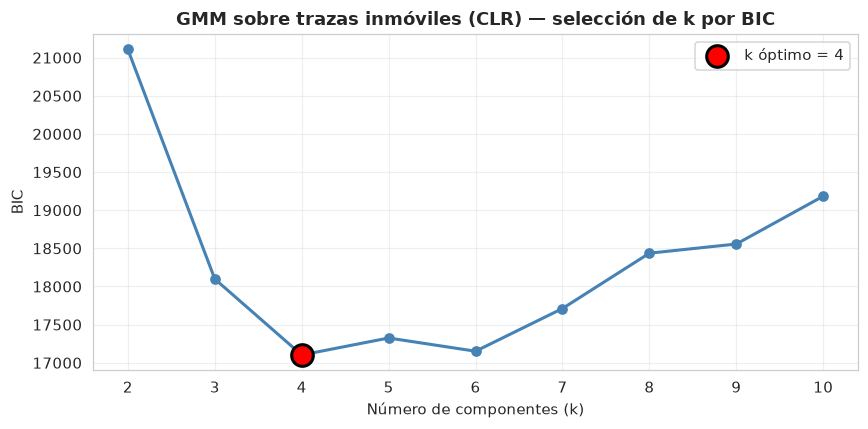

In [31]:
# ── CLR sobre trazas inmóviles ──
COLS_INMOV = GRUPOS['Trazas inmóviles (litología)']

def clr_transform(X_df, cols, min_pos=None):
    '''CLR de Aitchison: log(x / geom_mean). Ceros → min_pos/2.'''
    Xc = X_df[cols].copy()
    if min_pos is None:
        min_pos = {c: Xc[c][Xc[c] > 0].min() for c in cols}
    for c in cols:
        Xc[c] = Xc[c].replace(0, min_pos[c] / 2).clip(lower=min_pos[c] / 2)
    log_x = np.log(Xc)
    geom_mean = log_x.mean(axis=1)
    clr = log_x.subtract(geom_mean, axis=0)
    return clr, min_pos

CLR_train, min_pos_clr = clr_transform(X_train, COLS_INMOV)
CLR_test, _            = clr_transform(X_test, COLS_INMOV, min_pos=min_pos_clr)

# ── GMM + BIC para elegir k ──
sc_clr = StandardScaler().fit(CLR_train)
Z_train = sc_clr.transform(CLR_train)
Z_test  = sc_clr.transform(CLR_test)

ks = list(range(2, 11))
bics = [GaussianMixture(n_components=k, random_state=SEED, covariance_type='full').fit(Z_train).bic(Z_train)
        for k in ks]
k_opt = ks[int(np.argmin(bics))]

gmm = GaussianMixture(n_components=k_opt, random_state=SEED, covariance_type='full').fit(Z_train)
cluster_train = gmm.predict(Z_train)
cluster_test  = gmm.predict(Z_test)
prob_train = gmm.predict_proba(Z_train).max(axis=1)
prob_test  = gmm.predict_proba(Z_test).max(axis=1)

print(f'CLR sobre {len(COLS_INMOV)} trazas inmóviles → GMM óptimo: k={k_opt} (BIC={min(bics):.0f})')
print(f'Distribución de clusters en train: {dict(zip(*np.unique(cluster_train, return_counts=True)))}')

# ── Gráfico de BIC ──
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, bics, marker='o', lw=2, color='steelblue')
ax.scatter([k_opt], [min(bics)], s=200, color='red', edgecolors='black', linewidths=2, zorder=5,
           label=f'k óptimo = {k_opt}')
ax.set_xlabel('Número de componentes (k)'); ax.set_ylabel('BIC')
ax.set_title('GMM sobre trazas inmóviles (CLR) — selección de k por BIC', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/clustering_gmm_bic.png', bbox_inches='tight'); plt.show()

info_cluster = {'k_gmm': k_opt, 'bic_optimo': round(min(bics), 1),
                'n_por_cluster': dict(zip(*np.unique(cluster_train, return_counts=True)))}
pd.DataFrame({'k': ks, 'BIC': bics}).to_csv(f'{DIR_TAB}/clustering_gmm_bic.csv', index=False)

### Interacciones: percentil de pathfinder dentro del cluster

Para cada pathfinder principal (As, Sb, Tl, Bi, Mo, W), se calcula su **percentil dentro del cluster litológico** asignado. Esto captura la señal: *"¿esta muestra es anómala en As para su tipo de roca?"* — una anomalía en un cluster de 50 ppm promedio tiene significado distinto que en uno de 500 ppm.

In [32]:
PATHS_INTERACCION = ['As_ppm', 'Sb_ppm', 'Tl_ppm', 'Bi_ppm', 'Mo_ppm', 'W_ppm']

def crear_interacciones_cluster(Xsrc, clusters):
    '''Percentil de cada pathfinder dentro de su cluster litológico.'''
    d = {}
    for p in PATHS_INTERACCION:
        col = f'{p.replace("_ppm","")}_pctile_litho'
        vals = np.zeros(len(Xsrc))
        for k in np.unique(clusters):
            mask = clusters == k
            if mask.sum() < 2:
                continue
            from scipy.stats import rankdata
            vals[mask] = rankdata(Xsrc[p].values[mask]) / mask.sum()
        d[col] = vals
    return pd.DataFrame(d, index=Xsrc.index)

inter_train = crear_interacciones_cluster(X_train, cluster_train)
inter_test  = crear_interacciones_cluster(X_test, cluster_test)
FEATURES_INTER = list(inter_train.columns)

# Features de cluster: label + probabilidad
cl_train = pd.DataFrame({
    'cluster_litho': cluster_train,
    'cluster_litho_prob': prob_train,
}, index=X_train.index)
cl_test = pd.DataFrame({
    'cluster_litho': cluster_test,
    'cluster_litho_prob': prob_test,
}, index=X_test.index)
FEATURES_CLUSTER = list(cl_train.columns)

print(f'Features de cluster: {FEATURES_CLUSTER}')
print(f'Features de interacción (percentiles): {FEATURES_INTER}')

Features de cluster: ['cluster_litho', 'cluster_litho_prob']
Features de interacción (percentiles): ['As_pctile_litho', 'Sb_pctile_litho', 'Tl_pctile_litho', 'Bi_pctile_litho', 'Mo_pctile_litho', 'W_pctile_litho']


## Experimentos A/B

Se definen 4 conjuntos de features para evaluar el aporte incremental de cada componente del FE:

| Set | Contenido |
|---|---|
| **E0** Base | 43 features originales (sin FE) |
| **E1** +Índices epitermales | Base + 12 índices de alteración y zonación |
| **E2** +Cluster litológico | Base + cluster label + prob |
| **E3** +Todo | Base + índices + cluster + interacciones percentil |

Cada modelo se evalúa con la estrategia de balanceo que le resultó óptima en el Sprint 1.

In [33]:
# ── Definición de sets ──
E1_tr = pd.concat([X_train, FE_train], axis=1)
E1_te = pd.concat([X_test,  FE_test],  axis=1)
E2_tr = pd.concat([X_train, cl_train], axis=1)
E2_te = pd.concat([X_test,  cl_test],  axis=1)
E3_tr = pd.concat([X_train, FE_train, cl_train, inter_train], axis=1)
E3_te = pd.concat([X_test,  FE_test,  cl_test,  inter_test],  axis=1)

sets = {
    'E0 Base':             (X_train, X_test),
    'E1 +Índices':         (E1_tr, E1_te),
    'E2 +Cluster':         (E2_tr, E2_te),
    'E3 +Índ+Clust+Inter': (E3_tr, E3_te),
}
for nombre, (Xtr_, _) in sets.items():
    print(f'{nombre:24s}: {Xtr_.shape[1]} features')

E0 Base                 : 43 features
E1 +Índices             : 55 features
E2 +Cluster             : 45 features
E3 +Índ+Clust+Inter     : 63 features


In [34]:
print('\nEvaluando 4 experimentos × 11 modelos por F2_CV ...')
t0 = time.time()
f2_ab = pd.DataFrame(index=list(sets.keys()), columns=MODELOS, dtype=float)
for exp, (Xtr_, _) in sets.items():
    for mod in MODELOS:
        mu, _ = f2_cv(mod, Xtr_, y_train, balanceo=BAL_POR_MOD[mod])
        f2_ab.loc[exp, mod] = mu
    print(f'  {exp} completado')
print(f'Terminado en {time.time()-t0:.0f}s')
f2_ab = f2_ab.astype(float).round(4)
f2_ab.to_csv(f'{DIR_TAB}/experimentos_f2_cv.csv')

print('\nExperimentos A/B — F2_CV (media) · MÉTRICA DE DECISIÓN')
f2_ab.style.apply(resaltar_maximo, axis=0).format('{:.4f}')


Evaluando 4 experimentos × 11 modelos por F2_CV ...


  E0 Base completado
  E1 +Índices completado
  E2 +Cluster completado
  E3 +Índ+Clust+Inter completado
Terminado en 156s

Experimentos A/B — F2_CV (media) · MÉTRICA DE DECISIÓN


,KNN,Reg. Logística,SVM (RBF),MLP,Árbol de Decisión,Random Forest,ExtraTrees,HistGradientBoosting,XGBoost,LightGBM,CatBoost
E0 Base,0.6308,0.6233,0.6040,0.5959,0.5719,0.6322,0.6099,0.6532,0.6298,0.6484,0.6678
E1 +Índices,0.6433,0.6470,0.6545,0.5940,0.4922,0.6192,0.5968,0.6383,0.6204,0.6310,0.6730
E2 +Cluster,0.5801,0.6208,0.5973,0.5930,0.5327,0.6264,0.5826,0.6463,0.6424,0.6548,0.6604
E3 +Índ+Clust+Inter,0.6401,0.6337,0.6558,0.5845,0.5208,0.6440,0.6016,0.6144,0.6118,0.6303,0.6433


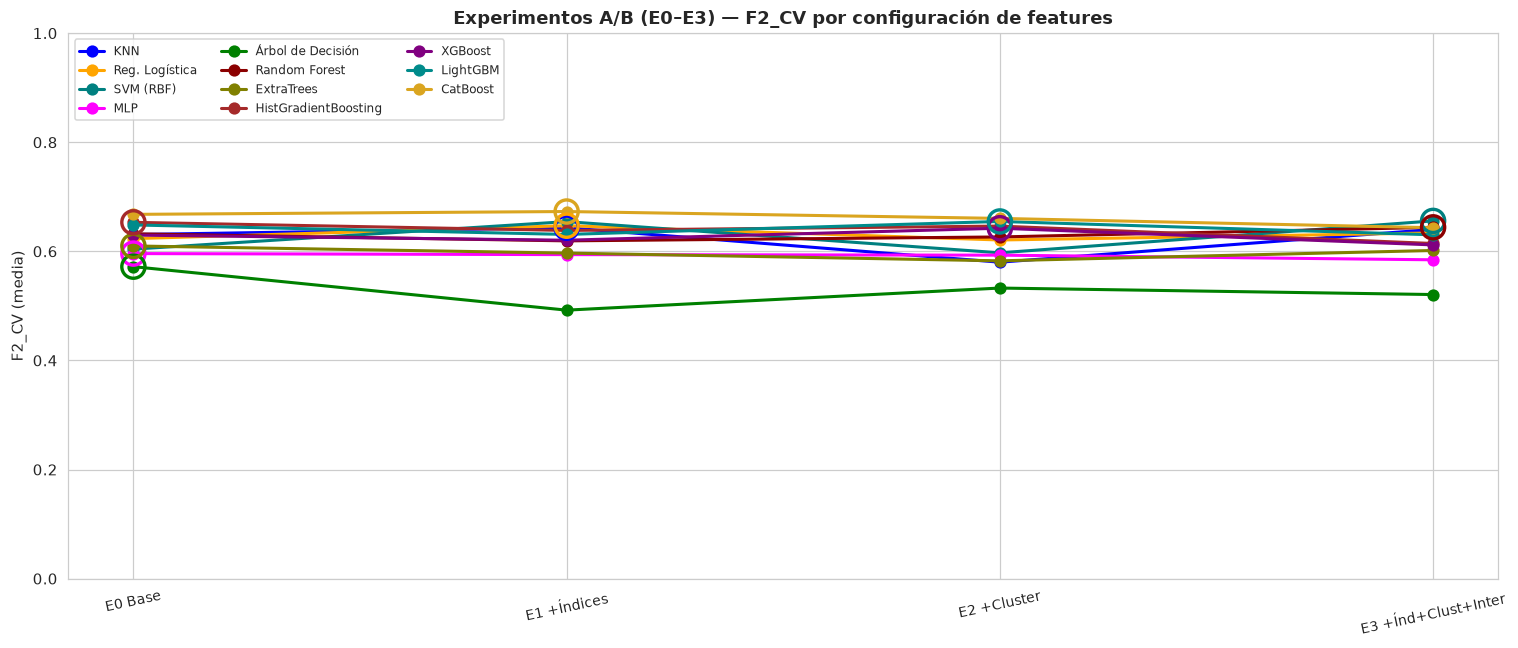

In [35]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(f2_ab.index))
for mod in MODELOS:
    ax.plot(x, f2_ab[mod].values, marker='o', lw=2, markersize=7, color=MODEL_COLORS[mod], label=mod)
    xi = int(np.argmax(f2_ab[mod].values))
    ax.scatter([xi], [f2_ab[mod].values[xi]], s=230, facecolors='none',
               edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(list(f2_ab.index), fontsize=9, rotation=12)
ax.set_ylabel('F2_CV (media)'); ax.set_ylim(0, 1)
ax.set_title('Experimentos A/B (E0–E3) — F2_CV por configuración de features', fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/experimentos_f2_cv_comparacion.png', bbox_inches='tight'); plt.show()

In [36]:
mejor_set_mod = {mod: f2_ab[mod].idxmax() for mod in MODELOS}
resumen_ab = pd.DataFrame({
    'Mejor set':       [mejor_set_mod[m] for m in MODELOS],
    'F2_CV (mejor)':   [round(f2_ab[m].max(), 4) for m in MODELOS],
    'F2_CV (E0 base)': [round(f2_ab.loc['E0 Base', m], 4) for m in MODELOS],
}, index=MODELOS)
resumen_ab['Δ F2_CV'] = (resumen_ab['F2_CV (mejor)'] - resumen_ab['F2_CV (E0 base)']).round(4)
resumen_ab.to_csv(f'{DIR_TAB}/experimentos_mejor_set.csv')
print('Mejor set por modelo (por F2_CV):')
resumen_ab

Mejor set por modelo (por F2_CV):


,Mejor set,F2_CV (mejor),F2_CV (E0 base),Δ F2_CV
KNN,E1 +Índices,0.6433,0.6308,0.0125
Reg. Logística,E1 +Índices,0.6470,0.6233,0.0237
SVM (RBF),E3 +Índ+Clust+Inter,0.6558,0.6040,0.0518
MLP,E0 Base,0.5959,0.5959,0.0000
Árbol de Decisión,E0 Base,0.5719,0.5719,0.0000
Random Forest,E3 +Índ+Clust+Inter,0.6440,0.6322,0.0118
ExtraTrees,E0 Base,0.6099,0.6099,0.0000
HistGradientBoosting,E0 Base,0.6532,0.6532,0.0000
XGBoost,E2 +Cluster,0.6424,0.6298,0.0126
LightGBM,E2 +Cluster,0.6548,0.6484,0.0064


## Optimización de hiperparámetros con Optuna

Se realiza una búsqueda bayesiana (TPE) de hiperparámetros para cada uno de los 11 modelos, usando su **mejor set de features** (A/B) y su **mejor balanceo** (Sprint 1). El objetivo es maximizar F2\_CV 5-fold.

**Presupuesto:** 50 trials para **todos** los modelos (decisión cerrada). `TPESampler(seed=SEED)` garantiza reproducibilidad.

**`class_weight`/`scale_pos_weight` en el espacio de búsqueda:** para los modelos que soportan pesos de clase, se incluye un parámetro booleano `use_class_weight` que activa `class_weight='balanced'` (sklearn/LightGBM), `auto_class_weights='Balanced'` (CatBoost) o `scale_pos_weight` (XGBoost). Esto permite que Optuna decida si los pesos de clase *combinados* con el sobremuestreo aportan o si es mejor uno solo.

In [37]:
N_TRIALS = 50

def espacio_optuna(mod, trial):
    '''Espacio de búsqueda por modelo, incluyendo class_weight como candidato.
    El parámetro use_class_weight es interno a Optuna; se traduce a class_weight/scale_pos_weight
    en los params devueltos, que van directo al constructor del clasificador.'''
    p = {}
    # ── class_weight/scale_pos_weight (para modelos que lo soporten) ──
    if mod in SOPORTA_PESOS:
        use_cw = trial.suggest_categorical('use_class_weight', [True, False])
    else:
        use_cw = False

    if mod == 'KNN':
        p['n_neighbors'] = trial.suggest_int('n_neighbors', 3, 15)
    elif mod == 'Reg. Logística':
        p['C'] = trial.suggest_float('C', 0.01, 10, log=True)
        p['max_iter'] = trial.suggest_categorical('max_iter', [500, 1000])
        if use_cw: p['class_weight'] = 'balanced'
    elif mod == 'SVM (RBF)':
        p['C'] = trial.suggest_float('C', 0.1, 10, log=True)
        p['gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto'])
        if use_cw: p['class_weight'] = 'balanced'
    elif mod == 'MLP':
        p['hidden_layer_sizes'] = trial.suggest_categorical('hidden_layer_sizes', [(50,), (100,), (100, 50)])
        p['alpha'] = trial.suggest_float('alpha', 1e-5, 1e-2, log=True)
        p['max_iter'] = trial.suggest_categorical('max_iter', [300, 500])
    elif mod == 'Árbol de Decisión':
        p['max_depth'] = trial.suggest_int('max_depth', 3, 20)
        p['min_samples_split'] = trial.suggest_int('min_samples_split', 2, 20)
        if use_cw: p['class_weight'] = 'balanced'
    elif mod == 'Random Forest':
        p['n_estimators'] = trial.suggest_int('n_estimators', 50, 300)
        p['max_depth'] = trial.suggest_int('max_depth', 5, 30)
        p['min_samples_leaf'] = trial.suggest_int('min_samples_leaf', 1, 10)
        if use_cw: p['class_weight'] = 'balanced'
    elif mod == 'ExtraTrees':
        p['n_estimators'] = trial.suggest_int('n_estimators', 50, 300)
        p['max_depth'] = trial.suggest_int('max_depth', 5, 30)
        p['min_samples_leaf'] = trial.suggest_int('min_samples_leaf', 1, 10)
        if use_cw: p['class_weight'] = 'balanced'
    elif mod == 'HistGradientBoosting':
        p['learning_rate'] = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        p['max_iter'] = trial.suggest_int('max_iter', 50, 300)
        p['max_leaf_nodes'] = trial.suggest_int('max_leaf_nodes', 15, 63)
        p['min_samples_leaf'] = trial.suggest_int('min_samples_leaf', 10, 50)
        p['l2_regularization'] = trial.suggest_float('l2_regularization', 0, 2)
        if use_cw: p['class_weight'] = 'balanced'
    elif mod == 'XGBoost':
        p['learning_rate'] = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        p['n_estimators'] = trial.suggest_int('n_estimators', 50, 300)
        p['max_depth'] = trial.suggest_int('max_depth', 3, 10)
        p['subsample'] = trial.suggest_float('subsample', 0.6, 1.0)
        p['reg_alpha'] = trial.suggest_float('reg_alpha', 0, 2)
        p['reg_lambda'] = trial.suggest_float('reg_lambda', 0.5, 3)
        if use_cw: p['scale_pos_weight'] = SPW
    elif mod == 'LightGBM':
        p['learning_rate'] = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        p['n_estimators'] = trial.suggest_int('n_estimators', 50, 300)
        p['num_leaves'] = trial.suggest_int('num_leaves', 20, 100)
        p['min_child_samples'] = trial.suggest_int('min_child_samples', 10, 50)
        if use_cw: p['class_weight'] = 'balanced'
    elif mod == 'CatBoost':
        p['iterations'] = trial.suggest_int('iterations', 50, 300)
        p['depth'] = trial.suggest_int('depth', 4, 10)
        p['learning_rate'] = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        if use_cw: p['auto_class_weights'] = 'Balanced'
    return p

def crear_clf_optuna(mod, params):
    '''Instancia un clasificador con hiperparámetros de Optuna.'''
    params = {k: v for k, v in params.items() if k != 'use_class_weight'}  # interno Optuna
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC
    from sklearn.neural_network import MLPClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
    if mod == 'KNN':                  return KNeighborsClassifier(**params)
    if mod == 'Reg. Logística':       return LogisticRegression(**params, random_state=SEED)
    if mod == 'SVM (RBF)':            return SVC(kernel='rbf', probability=True, **params, random_state=SEED)
    if mod == 'MLP':                  return MLPClassifier(**params, random_state=SEED)
    if mod == 'Árbol de Decisión':    return DecisionTreeClassifier(**params, random_state=SEED)
    if mod == 'Random Forest':        return RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)
    if mod == 'ExtraTrees':           return ExtraTreesClassifier(**params, random_state=SEED, n_jobs=-1)
    if mod == 'HistGradientBoosting': return HistGradientBoostingClassifier(**params, random_state=SEED)
    if mod == 'XGBoost':              return xgb.XGBClassifier(**params, random_state=SEED, eval_metric='logloss', tree_method='hist', n_jobs=-1)
    if mod == 'LightGBM':             return lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, n_jobs=-1)
    if mod == 'CatBoost':             return CatBoostClassifier(**params, random_seed=SEED, verbose=0, allow_writing_files=False)
    raise ValueError(mod)

def pipeline_optuna(mod, params, balanceo):
    pasos = [('sc', StandardScaler())]
    bal = crear_balanceador(balanceo)
    if bal is not None:
        pasos.append(('bal', bal))
    pasos.append(('clf', crear_clf_optuna(mod, params)))
    return ImbPipeline(pasos)

def make_objective(mod, Xtr_m, bal_m):
    def objective(trial):
        params = espacio_optuna(mod, trial)
        pipe = pipeline_optuna(mod, params, bal_m)
        sc = cross_val_score(pipe, Xtr_m, y_train, cv=CV5, scoring=F2_SCORER, n_jobs=-1)
        trial.set_user_attr('std', float(sc.std()))
        return sc.mean()
    return objective

studies, optuna_res = {}, {}
print(f'Optuna: {N_TRIALS} trials × {len(MODELOS)} modelos ...\n')
t_glob = time.time()
for mod in MODELOS:
    set_m = mejor_set_mod[mod]
    Xtr_m, _ = sets[set_m]
    bal_m = BAL_POR_MOD[mod]
    t0 = time.time()
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
    study.optimize(make_objective(mod, Xtr_m, bal_m), n_trials=N_TRIALS, n_jobs=1, show_progress_bar=False)
    studies[mod] = study
    f2_def, std_def = f2_cv(mod, Xtr_m, y_train, balanceo=bal_m)
    std_opt = float(study.best_trial.user_attrs.get('std', np.nan))
    optuna_res[mod] = {'set': set_m, 'bal': bal_m, 'n_trials': N_TRIALS,
                       'f2_default': float(f2_def), 'std_default': float(std_def),
                       'f2_optuna': float(study.best_value), 'std_optuna': std_opt,
                       'params': study.best_params}
    print(f'  {mod:22s} set={set_m:24s} F2_def={f2_def:.4f}±{std_def:.4f} → '
          f'F2_opt={study.best_value:.4f}±{std_opt:.4f} (Δ={study.best_value-f2_def:+.4f}, {time.time()-t0:.0f}s)')
print(f'\nOptuna total: {time.time()-t_glob:.0f}s')

Optuna: 50 trials × 11 modelos ...



  KNN                    set=E1 +Índices              F2_def=0.6433±0.0418 → F2_opt=0.6506±0.0232 (Δ=+0.0073, 7s)
  Reg. Logística         set=E1 +Índices              F2_def=0.6470±0.0433 → F2_opt=0.6612±0.0353 (Δ=+0.0142, 8s)
  SVM (RBF)              set=E3 +Índ+Clust+Inter      F2_def=0.6558±0.0508 → F2_opt=0.6797±0.0120 (Δ=+0.0239, 194s)
  MLP                    set=E0 Base                  F2_def=0.5959±0.0627 → F2_opt=0.6538±0.0664 (Δ=+0.0579, 411s)
  Árbol de Decisión      set=E0 Base                  F2_def=0.5719±0.0472 → F2_opt=0.6027±0.0396 (Δ=+0.0309, 14s)
  Random Forest          set=E3 +Índ+Clust+Inter      F2_def=0.6440±0.0246 → F2_opt=0.6858±0.0224 (Δ=+0.0417, 283s)
  ExtraTrees             set=E0 Base                  F2_def=0.6099±0.0292 → F2_opt=0.6839±0.0332 (Δ=+0.0740, 85s)
  HistGradientBoosting   set=E0 Base                  F2_def=0.6532±0.0251 → F2_opt=0.6993±0.0289 (Δ=+0.0460, 609s)
  XGBoost                set=E2 +Cluster              F2_def=0.6424±0.0249 → F

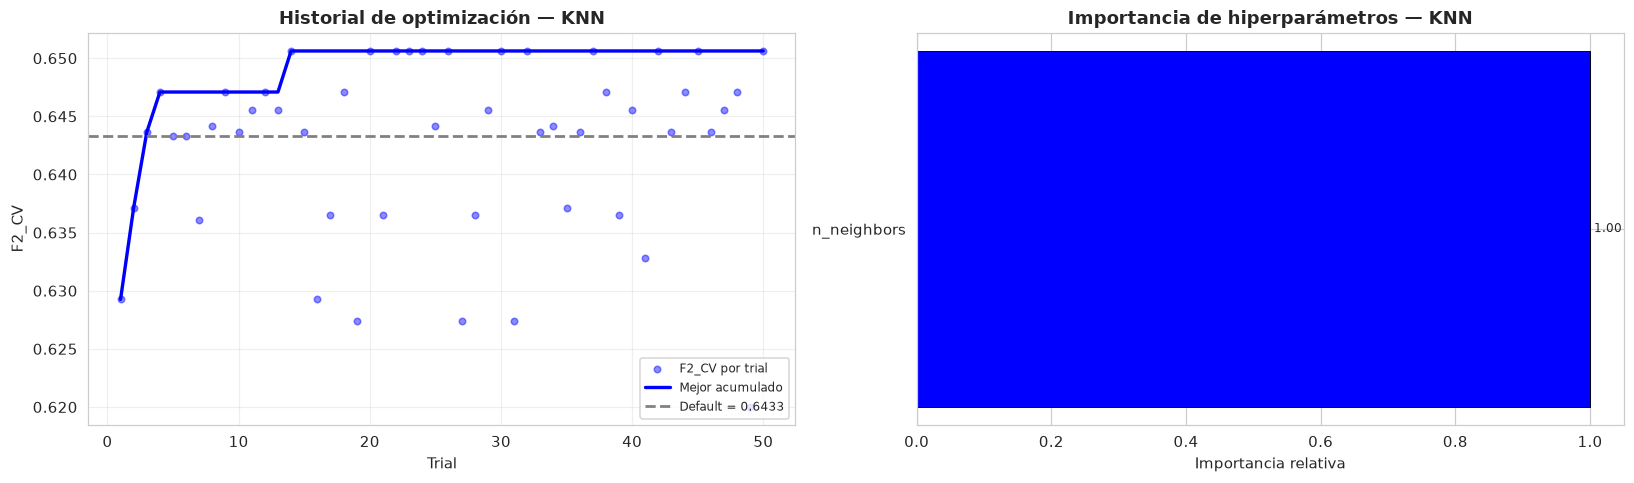

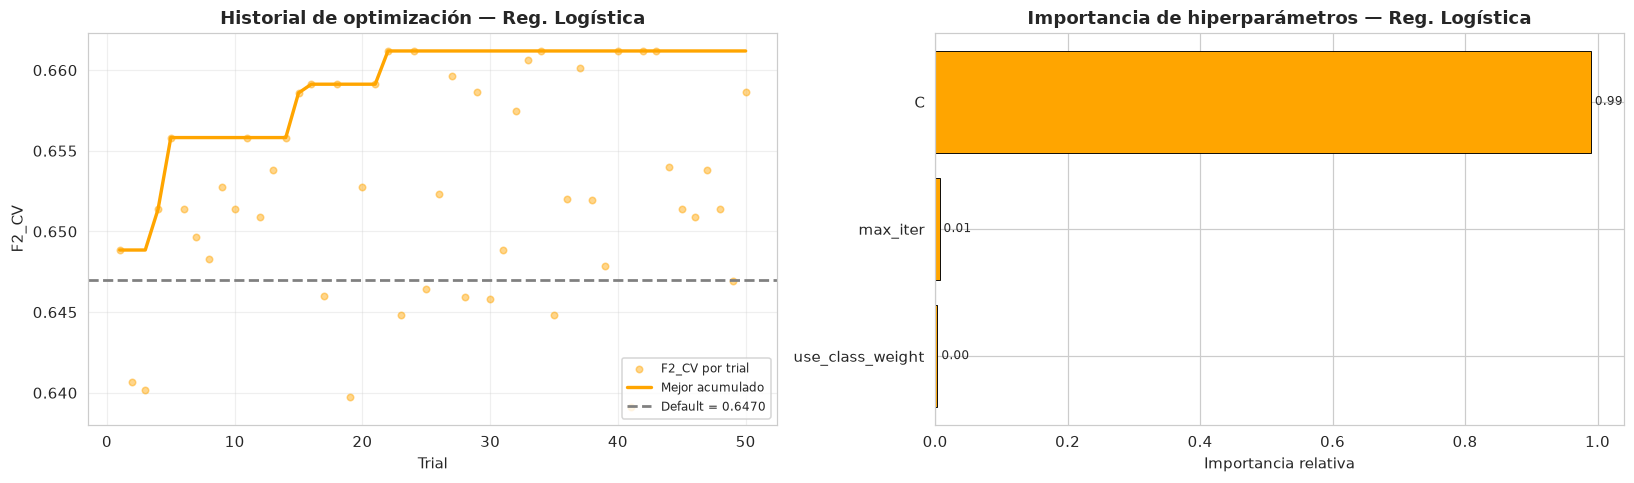

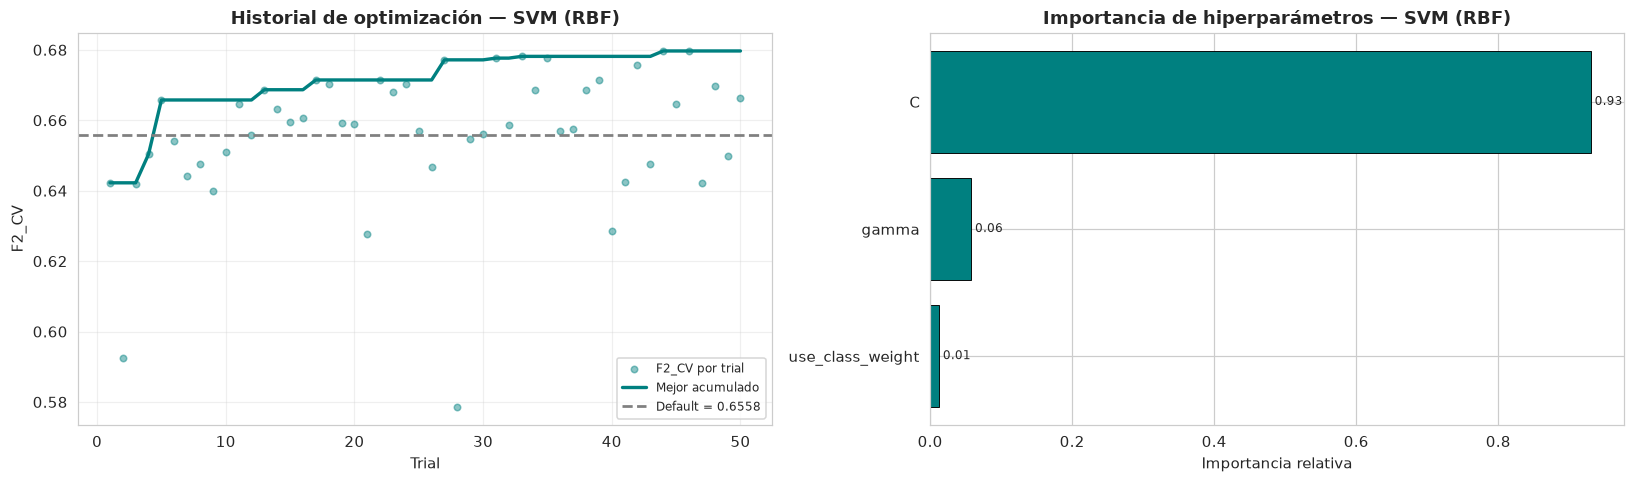

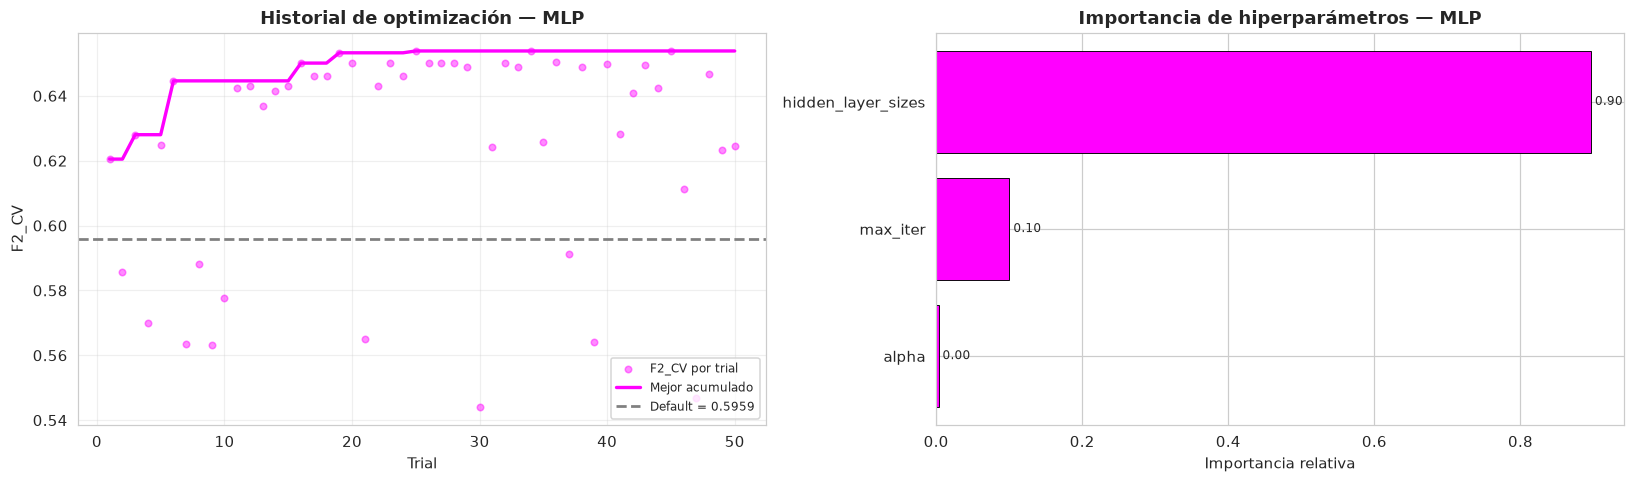

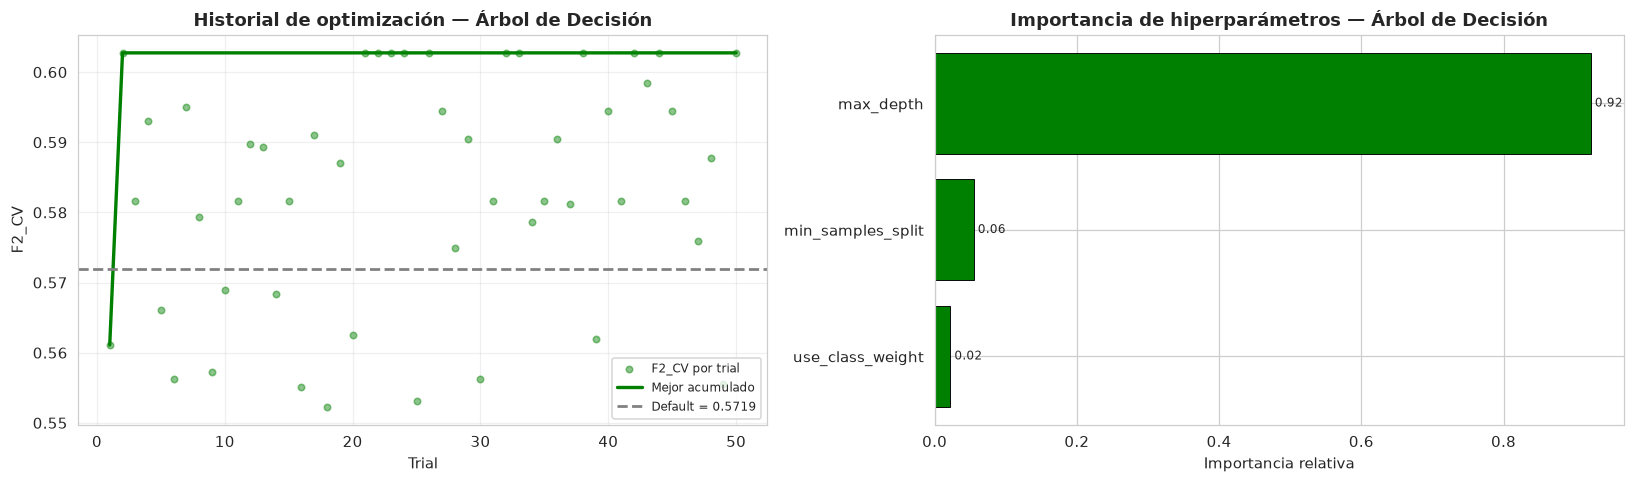

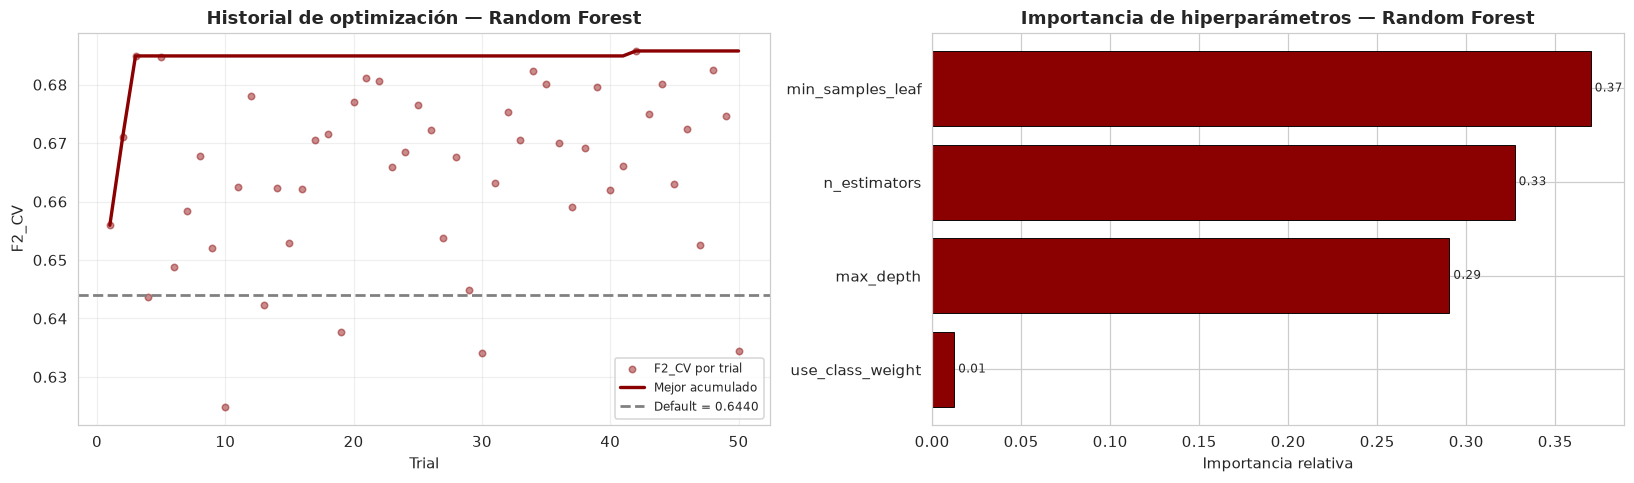

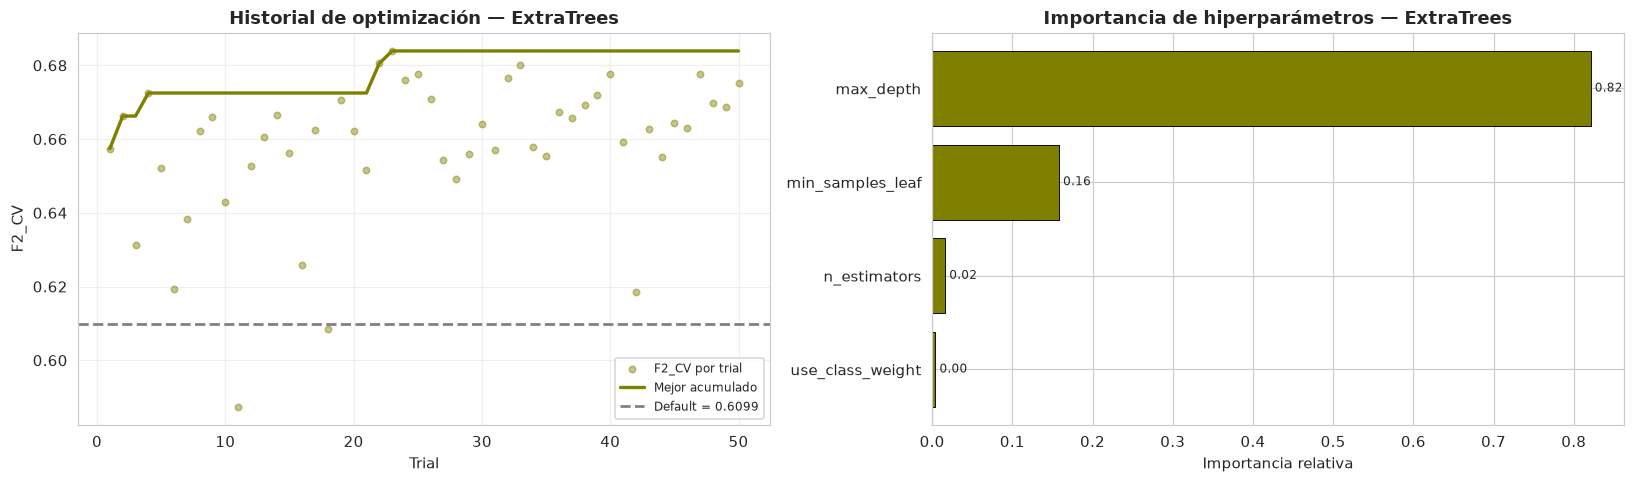

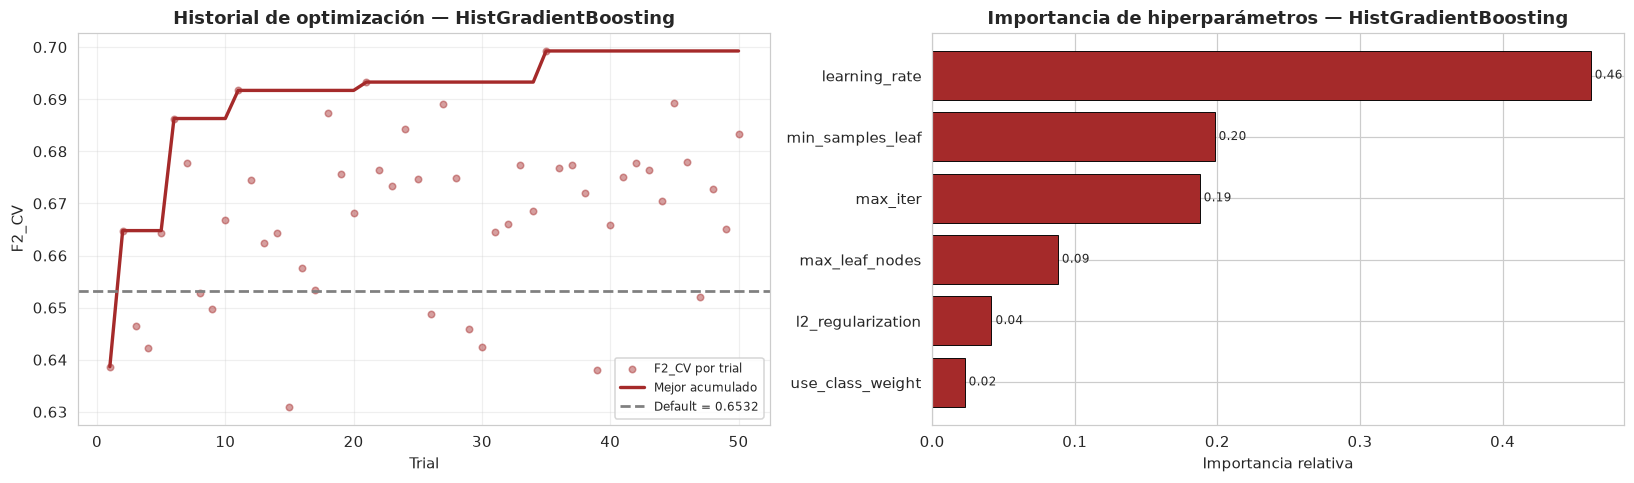

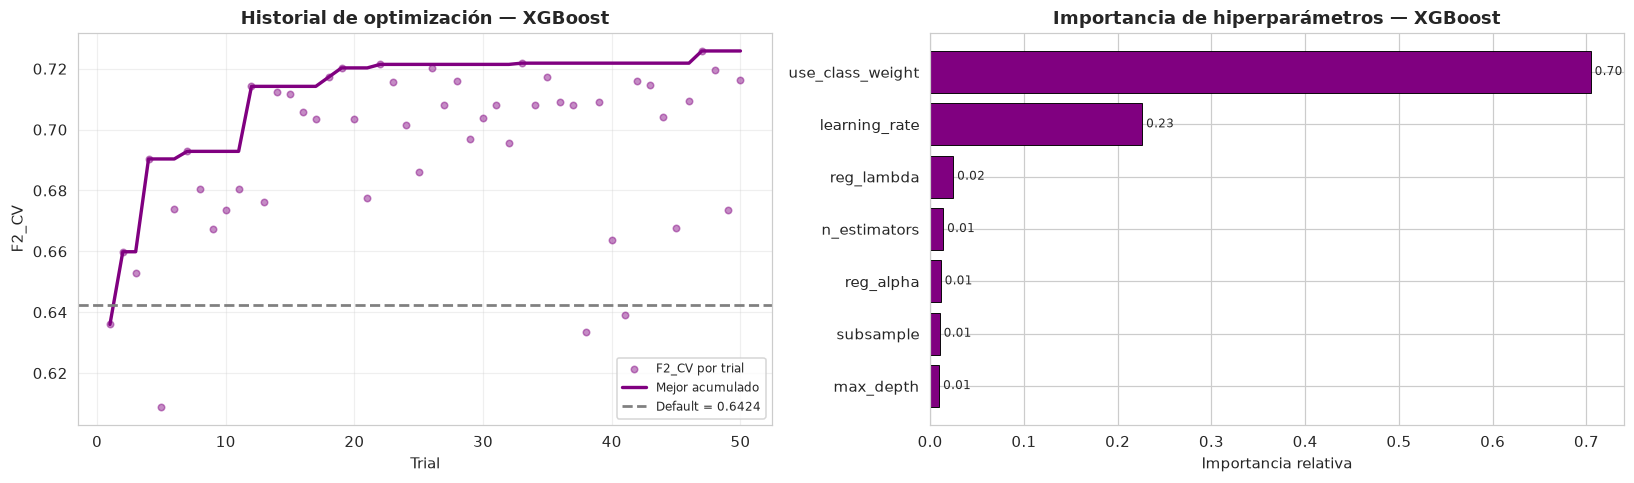

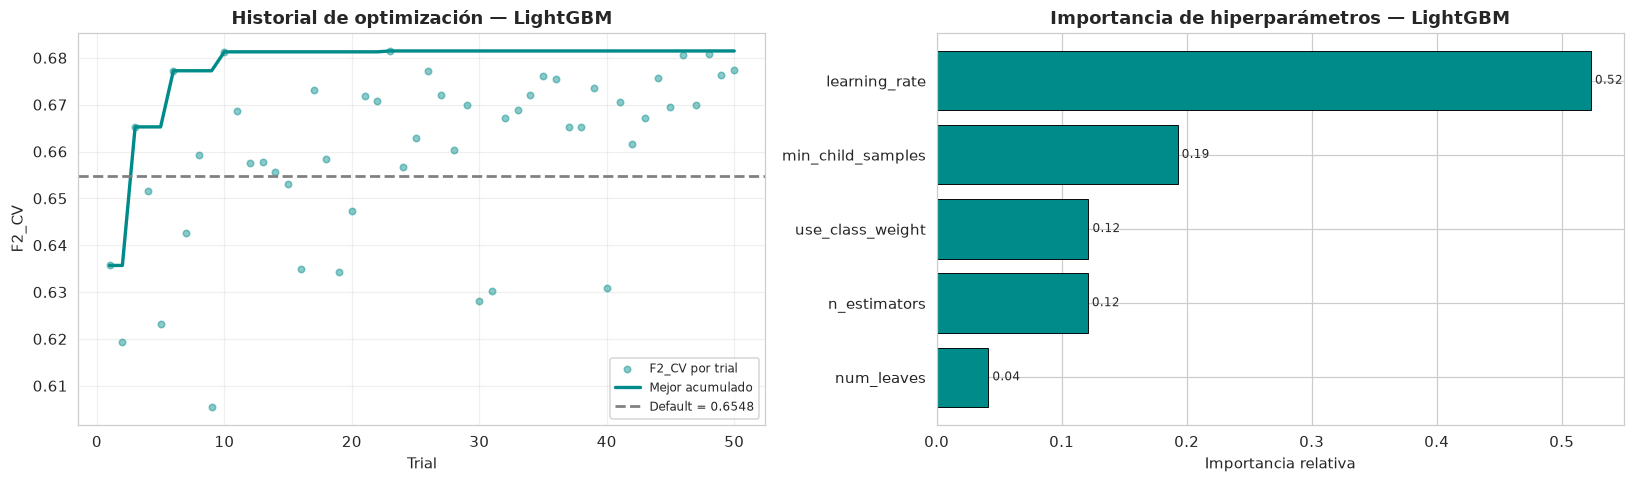

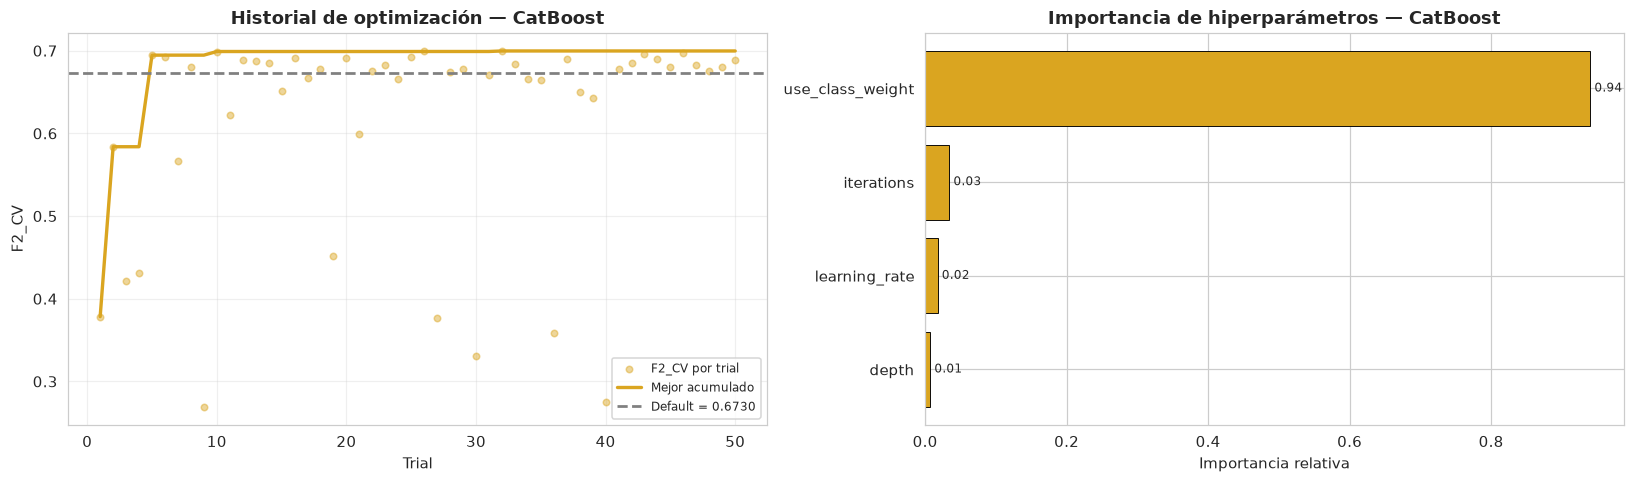

In [38]:
def slug(txt):
    return re.sub(r'[^a-z0-9]+', '_', txt.lower()).strip('_')

def plot_optuna_modelo(study, mod, f2_def):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    color = MODEL_COLORS[mod]
    vals = [t.value for t in study.trials if t.value is not None]
    best_run = np.maximum.accumulate(vals)
    xs = range(1, len(vals) + 1)
    axes[0].scatter(list(xs), vals, s=18, alpha=0.45, color=color, label='F2_CV por trial')
    axes[0].plot(list(xs), best_run, lw=2.2, color=color, label='Mejor acumulado')
    axes[0].axhline(f2_def, ls='--', lw=1.8, color='gray', label=f'Default = {f2_def:.4f}')
    axes[0].set_xlabel('Trial'); axes[0].set_ylabel('F2_CV')
    axes[0].set_title(f'Historial de optimización — {mod}', fontweight='bold')
    axes[0].legend(fontsize=8, loc='lower right'); axes[0].grid(True, alpha=0.3)
    try:
        imp = optuna.importance.get_param_importances(study)
        nombres = list(imp.keys())[::-1]; valores = [imp[k] for k in nombres]
        axes[1].barh(nombres, valores, color=color, edgecolor='black', linewidth=0.6)
        for i, v in enumerate(valores):
            axes[1].text(v, i, f' {v:.2f}', va='center', fontsize=8)
        axes[1].set_xlabel('Importancia relativa')
    except:
        axes[1].text(0.5, 0.5, 'Importancia no disponible', ha='center', va='center')
        axes[1].axis('off')
    axes[1].set_title(f'Importancia de hiperparámetros — {mod}', fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{DIR_FIG}/optuna_{slug(mod)}.png', bbox_inches='tight'); plt.show()

for mod in MODELOS:
    plot_optuna_modelo(studies[mod], mod, optuna_res[mod]['f2_default'])

## Comparación de resultados

In [39]:
tabla_opt = pd.DataFrame({
    'Mejor set':        [optuna_res[m]['set'] for m in MODELOS],
    'Balanceo':         [optuna_res[m]['bal'] for m in MODELOS],
    'F2_CV (default)':  [round(optuna_res[m]['f2_default'], 4) for m in MODELOS],
    '± std (def)':      [round(optuna_res[m]['std_default'], 4) for m in MODELOS],
    'F2_CV (Optuna)':   [round(optuna_res[m]['f2_optuna'], 4) for m in MODELOS],
    '± std (opt)':      [round(optuna_res[m]['std_optuna'], 4) for m in MODELOS],
}, index=MODELOS)
tabla_opt['Δ Optuna'] = (tabla_opt['F2_CV (Optuna)'] - tabla_opt['F2_CV (default)']).round(4)
usa_opt = tabla_opt['F2_CV (Optuna)'] >= tabla_opt['F2_CV (default)']
tabla_opt['F2_CV (mejor)'] = np.where(usa_opt, tabla_opt['F2_CV (Optuna)'], tabla_opt['F2_CV (default)']).round(4).astype(float)
tabla_opt['± std (mejor)'] = np.where(usa_opt, tabla_opt['± std (opt)'], tabla_opt['± std (def)']).round(4).astype(float)
tabla_opt = tabla_opt.sort_values('F2_CV (mejor)', ascending=False)
tabla_opt.to_csv(f'{DIR_TAB}/optuna_comparativa_modelos.csv')
print('Comparativa Optuna — 11 modelos (decisión por F2_CV):')
tabla_opt.style.apply(resaltar_maximo, axis=0, subset=['F2_CV (mejor)']).format(
    {'F2_CV (default)': '{:.4f}', '± std (def)': '{:.4f}',
     'F2_CV (Optuna)': '{:.4f}', '± std (opt)': '{:.4f}',
     'Δ Optuna': '{:+.4f}', 'F2_CV (mejor)': '{:.4f}', '± std (mejor)': '{:.4f}'})

Comparativa Optuna — 11 modelos (decisión por F2_CV):


,Mejor set,Balanceo,F2_CV (default),± std (def),F2_CV (Optuna),± std (opt),Δ Optuna,F2_CV (mejor),± std (mejor)
XGBoost,E2 +Cluster,SMOTE,0.6424,0.0249,0.7258,0.0239,+0.0834,0.7258,0.0239
CatBoost,E1 +Índices,Pesos de clase,0.6730,0.0262,0.6997,0.0236,+0.0267,0.6997,0.0236
HistGradientBoosting,E0 Base,SMOTETomek,0.6532,0.0251,0.6993,0.0289,+0.0461,0.6993,0.0289
Random Forest,E3 +Índ+Clust+Inter,SMOTE,0.6440,0.0246,0.6858,0.0224,+0.0418,0.6858,0.0224
ExtraTrees,E0 Base,ADASYN,0.6099,0.0292,0.6839,0.0332,+0.0740,0.6839,0.0332
LightGBM,E2 +Cluster,SMOTETomek,0.6548,0.0219,0.6815,0.0490,+0.0267,0.6815,0.0490
SVM (RBF),E3 +Índ+Clust+Inter,RandomOverSampler,0.6558,0.0508,0.6797,0.0120,+0.0239,0.6797,0.0120
Reg. Logística,E1 +Índices,RandomOverSampler,0.6470,0.0433,0.6612,0.0353,+0.0142,0.6612,0.0353
MLP,E0 Base,ADASYN,0.5959,0.0627,0.6538,0.0664,+0.0579,0.6538,0.0664
KNN,E1 +Índices,ADASYN,0.6433,0.0418,0.6506,0.0232,+0.0073,0.6506,0.0232


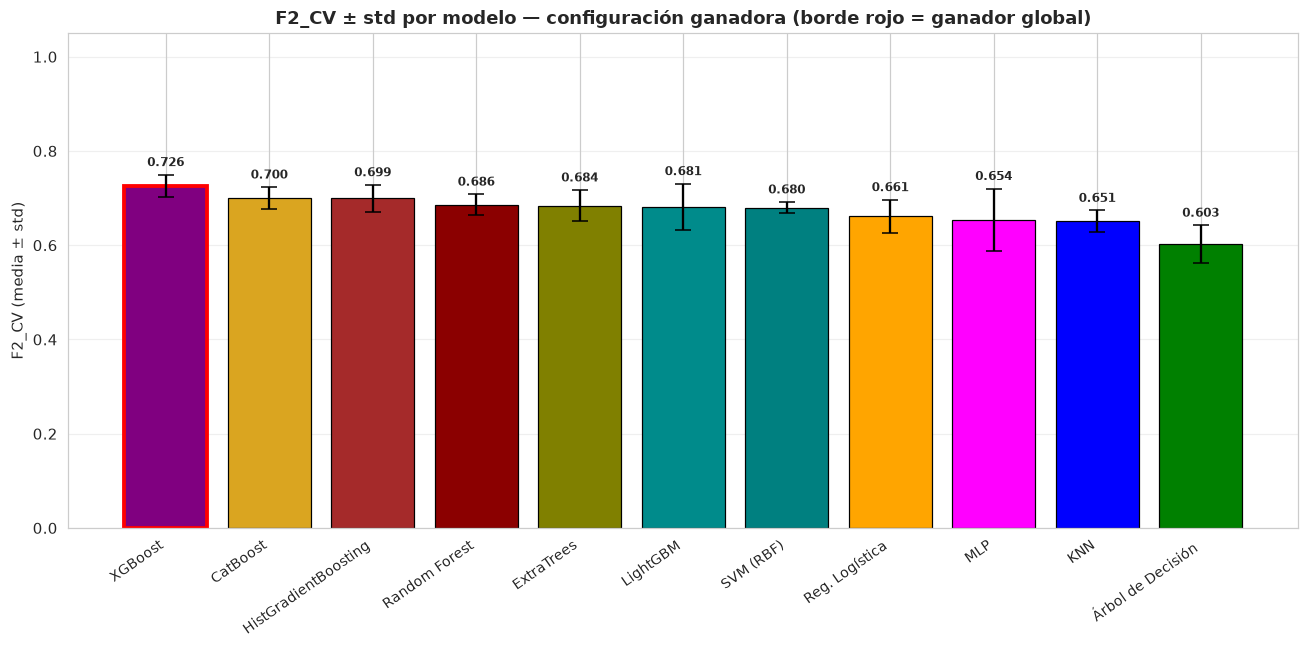

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))
orden = tabla_opt.index.tolist()
medias = tabla_opt['F2_CV (mejor)'].values.astype(float)
stds = tabla_opt['± std (mejor)'].values.astype(float)
colores = [MODEL_COLORS[m] for m in orden]
barras = ax.bar(range(len(orden)), medias, yerr=stds, capsize=5,
                color=colores, edgecolor='black', linewidth=0.8,
                error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
idx_win = int(np.argmax(medias))
barras[idx_win].set_edgecolor('red'); barras[idx_win].set_linewidth(2.5)
for i, (mu, sd) in enumerate(zip(medias, stds)):
    ax.text(i, mu + sd + 0.012, f'{mu:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(orden))); ax.set_xticklabels(orden, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('F2_CV (media ± std)'); ax.set_ylim(0, 1.05)
ax.set_title('F2_CV ± std por modelo — configuración ganadora (borde rojo = ganador global)', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/optuna_f2_cv_barras.png', bbox_inches='tight'); plt.show()

## Selección de los top-3 por familia

Para garantizar la **diversidad** del stacking en el Sprint 4, el top-3 se elige como el **mejor modelo de cada familia**, no los 3 mejores globales. Las familias son:

| Familia | Modelos |
|---|---|
| Boosting | HistGradientBoosting, XGBoost, LightGBM, CatBoost |
| Bagging/Árbol | Random Forest, ExtraTrees, Árbol de Decisión |
| Lineal/Kernel | Reg. Logística, SVM (RBF) |
| Red neuronal | MLP |
| Vecinos | KNN |

Se seleccionan las **3 familias** cuyo campeón tenga el mayor F2\_CV. Esto asegura que las bases del stacking sean *fundamentalmente distintas* en su mecanismo de aprendizaje (correlación de residuos baja).

In [42]:
# ── Mejor modelo por familia ──
f2_final_mod = {mod: max(optuna_res[mod]['f2_optuna'], optuna_res[mod]['f2_default']) for mod in MODELOS}

campeon_por_familia = {}
for fam, miembros in FAMILIAS.items():
    mejor = max(miembros, key=lambda m: f2_final_mod[m])
    campeon_por_familia[fam] = {'modelo': mejor, 'f2_cv': round(f2_final_mod[mejor], 4)}

ranking_fam = sorted(campeon_por_familia.items(), key=lambda x: x[1]['f2_cv'], reverse=True)
TOP_3_FAMILIAS = ranking_fam[:3]
TOP_3 = [info['modelo'] for _, info in TOP_3_FAMILIAS]

print('Campeón por familia:')
for fam, info in ranking_fam:
    marca = ' ← TOP-3' if info['modelo'] in TOP_3 else ''
    print(f'  {fam:15s}: {info["modelo"]:22s} F2_CV={info["f2_cv"]:.4f}{marca}')
print(coral(f'\nTop-3 seleccionados (diverso por familia): {TOP_3}'))

pd.DataFrame(ranking_fam, columns=['Familia', 'Info']).to_csv(f'{DIR_TAB}/top3_familias.csv', index=False)

Campeón por familia:
  Boosting       : XGBoost                F2_CV=0.7258 ← TOP-3
  Bagging/Árbol  : Random Forest          F2_CV=0.6858 ← TOP-3
  Lineal/Kernel  : SVM (RBF)              F2_CV=0.6797 ← TOP-3
  Red neuronal   : MLP                    F2_CV=0.6538
  Vecinos        : KNN                    F2_CV=0.6506

Top-3 seleccionados (diverso por familia): ['XGBoost', 'Random Forest', 'SVM (RBF)']


### Verificación de estabilidad por semillas

Para demostrar que el ranking del top-3 no es un artefacto de los folds, se repite el F2\_CV con 3 semillas adicionales y se reporta la media ± std global.

In [44]:
SEMILLAS_EXTRA = [123, 456, 789]
print(f'Verificación de estabilidad (semillas extra: {SEMILLAS_EXTRA}):')
estabilidad = {}
for mod in TOP_3:
    set_m = optuna_res[mod]['set']
    Xtr_m, _ = sets[set_m]
    bal_m = optuna_res[mod]['bal']
    params_m = optuna_res[mod]['params']
    usa_optuna = optuna_res[mod]['f2_optuna'] >= optuna_res[mod]['f2_default']
    f2s = [f2_final_mod[mod]]
    for s in SEMILLAS_EXTRA:
        cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        if usa_optuna and params_m:
            pipe = pipeline_optuna(mod, params_m, bal_m)
        else:
            pipe = construir_pipeline(mod, bal_m)
        sc = cross_val_score(pipe, Xtr_m, y_train, cv=cv_s, scoring=F2_SCORER, n_jobs=-1)
        f2s.append(sc.mean())
    estabilidad[mod] = {'f2_semillas': f2s, 'media': np.mean(f2s), 'std': np.std(f2s)}
    print(f'  {mod:22s}: semillas={[round(f,4) for f in f2s]} → media={np.mean(f2s):.4f} ± {np.std(f2s):.4f}')

pd.DataFrame({mod: {'F2_media': round(v['media'], 4), 'F2_std': round(v['std'], 4)}
              for mod, v in estabilidad.items()}).T.to_csv(f'{DIR_TAB}/top3_estabilidad_semillas.csv')

Verificación de estabilidad (semillas extra: [123, 456, 789]):


  XGBoost               : semillas=[0.7258, np.float64(0.6369), np.float64(0.6247), np.float64(0.6504)] → media=0.6595 ± 0.0394
  Random Forest         : semillas=[0.6858, np.float64(0.6737), np.float64(0.6536), np.float64(0.6359)] → media=0.6622 ± 0.0190
  SVM (RBF)             : semillas=[0.6797, np.float64(0.6559), np.float64(0.6846), np.float64(0.6708)] → media=0.6727 ± 0.0109


## Evaluación en hold-out (informativa)

Se evalúan los top-3 en hold-out **una sola vez**, con fines informativos. La decisión ya fue tomada por F2\_CV.

In [45]:
METRICAS = ['F2', 'Recall', 'Precision', 'F1', 'Accuracy', 'AUC-ROC', 'AUC-PR']
res_ho = {}
modelos_fit_s2 = {}
for mod in TOP_3:
    set_m = optuna_res[mod]['set']
    Xtr_m, Xte_m = sets[set_m]
    bal_m = optuna_res[mod]['bal']
    usa_opt = optuna_res[mod]['f2_optuna'] >= optuna_res[mod]['f2_default']
    if usa_opt:
        pipe = pipeline_optuna(mod, optuna_res[mod]['params'], bal_m)
    else:
        pipe = construir_pipeline(mod, bal_m)
    pipe.fit(Xtr_m, y_train)
    y_pred = pipe.predict(Xte_m)
    y_sco  = scores_pos(pipe, Xte_m)
    res_ho[mod] = metricas_holdout(y_test, y_pred, y_sco)
    res_ho[mod]['_pred'] = y_pred; res_ho[mod]['_score'] = y_sco
    modelos_fit_s2[mod] = pipe

tabla_ho = pd.DataFrame({m: {k: res_ho[m][k] for k in METRICAS} for m in TOP_3}).T[METRICAS].round(4)
tabla_ho.to_csv(f'{DIR_TAB}/top3_holdout_metricas.csv')
print('Métricas en HOLD-OUT (informativas — top-3):')
tabla_ho.style.apply(resaltar_maximo, axis=0, subset=METRICAS).format('{:.4f}', subset=METRICAS)

Métricas en HOLD-OUT (informativas — top-3):


,F2,Recall,Precision,F1,Accuracy,AUC-ROC,AUC-PR
XGBoost,0.6985,0.7308,0.5938,0.6552,0.9063,0.9346,0.7175
Random Forest,0.6993,0.7692,0.5128,0.6154,0.8829,0.9163,0.6572
SVM (RBF),0.7009,0.8654,0.3982,0.5455,0.8244,0.9141,0.6303


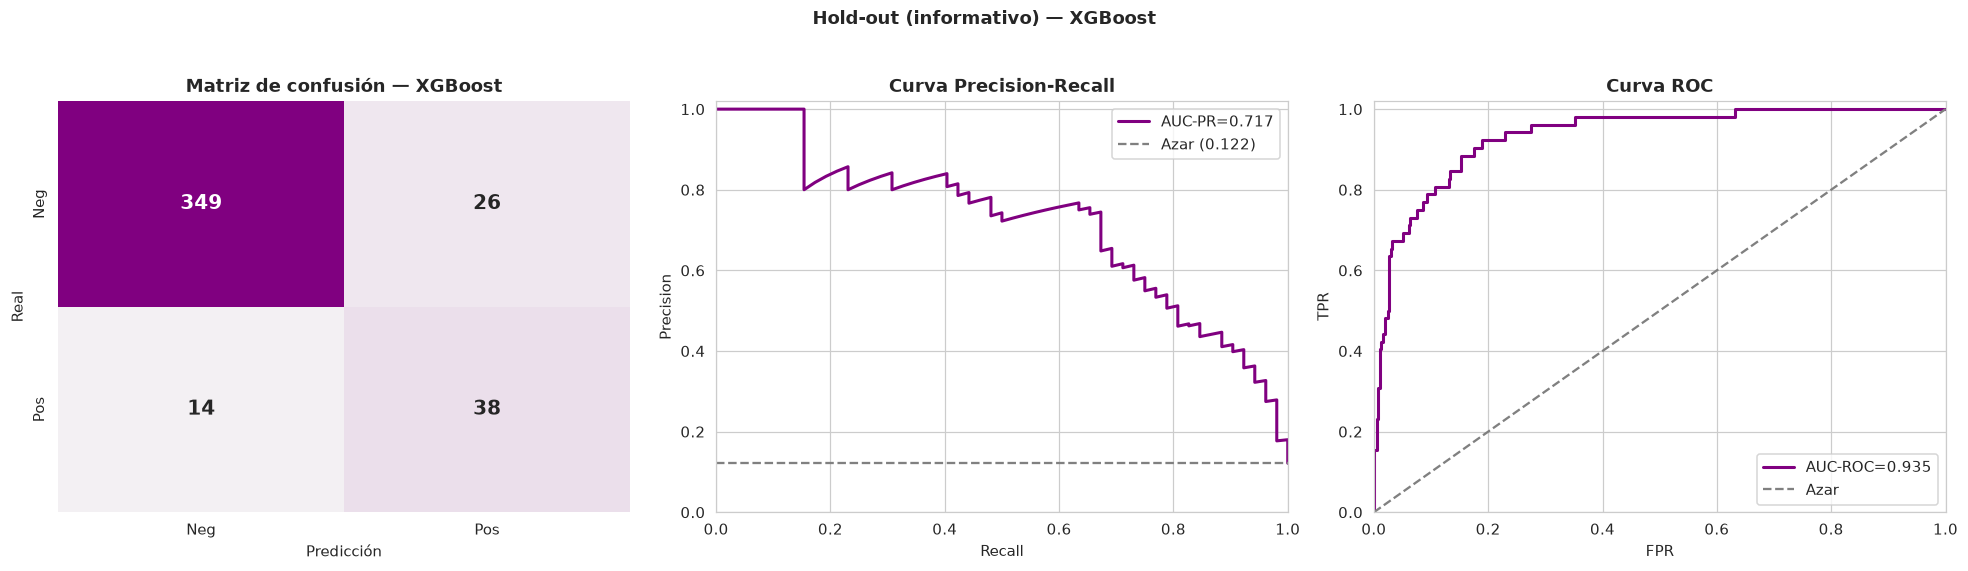

In [46]:
# ── Curvas del ganador (top-1) ──
mejor_modelo = TOP_3[0]
y_pred_g = res_ho[mejor_modelo]['_pred']
y_sco_g  = res_ho[mejor_modelo]['_score']
metr_g   = {k: res_ho[mejor_modelo][k] for k in METRICAS}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred_g)
sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[0],
            cmap=sns.light_palette(MODEL_COLORS[mejor_modelo], as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[0].set_title(f'Matriz de confusión — {mejor_modelo}', fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

p, r, _ = precision_recall_curve(y_test, y_sco_g)
axes[1].plot(r, p, color=MODEL_COLORS[mejor_modelo], lw=2, label=f'AUC-PR={metr_g["AUC-PR"]:.3f}')
axes[1].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva Precision-Recall', fontweight='bold'); axes[1].legend()

fpr, tpr, _ = roc_curve(y_test, y_sco_g)
axes[2].plot(fpr, tpr, color=MODEL_COLORS[mejor_modelo], lw=2, label=f'AUC-ROC={metr_g["AUC-ROC"]:.3f}')
axes[2].plot([0, 1], [0, 1], '--', color='gray', label='Azar')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1.02)
axes[2].set_title('Curva ROC', fontweight='bold'); axes[2].legend(loc='lower right')
plt.suptitle(f'Hold-out (informativo) — {mejor_modelo}', fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/top1_curvas_holdout.png', bbox_inches='tight'); plt.show()

## Persistencia de artefactos

Se guardan los datasets transformados con FE, los modelos de clustering, los pipelines del top-3 y las configuraciones para que el Sprint 3 los cargue directamente.

In [47]:
# ── Guardar datasets de cada set ──
for nombre, (Xtr_, Xte_) in sets.items():
    tag = nombre.split()[0]
    Xtr_.to_parquet(f'{DIR_DATA}/X_{tag}_train.parquet')
    Xte_.to_parquet(f'{DIR_DATA}/X_{tag}_test.parquet')

# ── Guardar modelos de clustering ──
clustering_artifacts = {'gmm': gmm, 'scaler_clr': sc_clr, 'min_pos_clr': min_pos_clr,
                        'cols_inmov': COLS_INMOV, 'k_opt': k_opt}
joblib.dump(clustering_artifacts, f'{DIR_MODELS}/clustering_litho.pkl')

# ── Guardar pipelines del top-3 ──
modelos_guardados_s2 = {}
for mod in TOP_3:
    fname = 'modelo_' + re.sub(r'[^a-z0-9]+', '_', mod.lower()).strip('_') + '.pkl'
    ruta = f'{DIR_MODELS}/{fname}'
    joblib.dump(modelos_fit_s2[mod], ruta)
    modelos_guardados_s2[mod] = ruta

# ── Guardar configs del top-3 ──
top3_info = {}
for mod in TOP_3:
    usa_opt = optuna_res[mod]['f2_optuna'] >= optuna_res[mod]['f2_default']
    top3_info[mod] = {
        'set': optuna_res[mod]['set'],
        'balanceo': optuna_res[mod]['bal'],
        'familia': [f for f, ms in FAMILIAS.items() if mod in ms][0],
        'usa_optuna': usa_opt,
        'params': optuna_res[mod]['params'] if usa_opt else {},
        'f2_cv': round(f2_final_mod[mod], 4),
    }
with open(f'{DIR_DATA}/top3_config.json', 'w') as f:
    json.dump(top3_info, f, indent=2, ensure_ascii=False)

# ── Features de cada set ──
sets_features = {nombre: list(Xtr_.columns) for nombre, (Xtr_, _) in sets.items()}
with open(f'{DIR_DATA}/sets_features.json', 'w') as f:
    json.dump(sets_features, f, indent=2, ensure_ascii=False)

print(f'Artefactos persistidos en {OUT}/')
print(f'  Top-3: {TOP_3}')
print(f'  Modelos guardados: {list(modelos_guardados_s2.keys())}')

Artefactos persistidos en outputs_sprint2/
  Top-3: ['XGBoost', 'Random Forest', 'SVM (RBF)']
  Modelos guardados: ['XGBoost', 'Random Forest', 'SVM (RBF)']


## Resumen

In [48]:
f2_ganador = f2_final_mod[mejor_modelo]
config_ganador = '+ Optuna' if optuna_res[mejor_modelo]['f2_optuna'] >= optuna_res[mejor_modelo]['f2_default'] else 'Default'
set_ganador = optuna_res[mejor_modelo]['set']
bal_ganador = optuna_res[mejor_modelo]['bal']

resumen2 = {
    'sprint': 2,
    'nombre': 'FE epitermal con bibliografía, clustering litológico CLR+GMM, Optuna',
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'protocolo': (f'Decisión por F2_CV 5-fold; 12 índices epitermales con citas; '
                  f'clustering litológico CLR+GMM (k={k_opt}); '
                  f'Optuna {N_TRIALS} trials con class_weight en espacio de búsqueda; '
                  f'top-3 por familia; hold-out informativo.'),
    'metrica_decision': 'f2',
    'metrica_principal': 'recall',
    'mejor_modelo': mejor_modelo,
    'mejor_set': set_ganador,
    'config_final': config_ganador,
    'metodo_balanceo': bal_ganador,
    'f2_cv_final': round(f2_ganador, 4),
    'f2_holdout': round(res_ho[mejor_modelo]['F2'], 4),
    'f2_final': round(f2_ganador, 4),
    'f2_sprint0': RESUMEN_S0['f2_final'],
    'f2_sprint1': F2_SPRINT1,
    'mejora_vs_sprint1': round(f2_ganador - F2_SPRINT1, 4),
    'metricas_holdout': {m: round(float(res_ho[mejor_modelo][m]), 4) for m in METRICAS},
    'top_3': TOP_3,
    'top3_config': top3_info,
    'top3_familias': {fam: info for fam, info in ranking_fam},
    'campeon_por_familia': campeon_por_familia,
    'familias': {fam: miembros for fam, miembros in FAMILIAS.items()},
    'best_params_optuna': optuna_res[mejor_modelo]['params'] if config_ganador == '+ Optuna' else {},
    'n_trials_optuna': N_TRIALS,
    'optuna_comparativa': {m: {'set': optuna_res[m]['set'], 'balanceo': optuna_res[m]['bal'],
                               'f2_default': round(optuna_res[m]['f2_default'], 4),
                               'f2_optuna': round(optuna_res[m]['f2_optuna'], 4),
                               'params': optuna_res[m]['params']} for m in MODELOS},
    'estabilidad_semillas': {mod: {'media': round(v['media'], 4), 'std': round(v['std'], 4)}
                            for mod, v in estabilidad.items()},
    'features_epitermales': FEATURES_FE,
    'features_cluster': FEATURES_CLUSTER,
    'features_interaccion': FEATURES_INTER,
    'cluster_info': info_cluster,
    'f2_cv_experimentos': {exp: {m: float(f2_ab.loc[exp, m]) for m in MODELOS} for exp in f2_ab.index},
    'f2_cv_por_modelo': {m: round(f2_final_mod[m], 4) for m in MODELOS},
    'n_features_base': len(FEATURES_BASE),
    'features_base': FEATURES_BASE,
    'grupos_geoquimicos': GRUPOS,
    'modelos_guardados': modelos_guardados_s2,
    'versiones_librerias': versiones,
    'rutas': {'data': DIR_DATA, 'models': DIR_MODELS, 'figures': DIR_FIG, 'tables': DIR_TAB},
}
def _sanitize(obj):
    # Convierte recursivamente tipos numpy a nativos Python para json.dump
    if isinstance(obj, dict):
        return {_sanitize(k): _sanitize(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_sanitize(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

with open(f'{OUT}/resumen_sprint2.json', 'w') as f:
    json.dump(_sanitize(resumen2), f, indent=2, ensure_ascii=False)

print('════════════════════ RESUMEN SPRINT 2 ════════════════════')
print(f'FE: {len(FEATURES_FE)} índices epitermales (5 alteración + 4 zonación pathfinders + 3 LILE)')
print(f'Clustering: GMM (k={k_opt}) sobre CLR de {len(COLS_INMOV)} trazas inmóviles')
print(f'Interacciones: {len(FEATURES_INTER)} percentiles de pathfinder por cluster litológico')
print(f'Optuna: {N_TRIALS} trials × {len(MODELOS)} modelos, con class_weight en espacio de búsqueda')
print(coral(f'\nGANADOR: {mejor_modelo} con "{set_ganador}"'))
print(f'   Config: {config_ganador} | Balanceo: {bal_ganador}')
print(coral(f'   F2_CV       = {f2_ganador:.4f}   (decisión)'))
print(f'   F2 hold-out = {res_ho[mejor_modelo]["F2"]:.4f} | Recall hold-out = {res_ho[mejor_modelo]["Recall"]:.4f}   (informativo)')
print(f'\nTop-3 por familia (para stacking diverso en Sprint 4):')
for i, (fam, info) in enumerate(TOP_3_FAMILIAS, 1):
    est = estabilidad.get(info['modelo'], {})
    print(f'  {i}. [{fam}] {info["modelo"]:22s} F2_CV={info["f2_cv"]:.4f} '
          f'| estab.={est.get("media",0):.4f}±{est.get("std",0):.4f}')
print(f'\nEvolución del proyecto (por F2_CV):')
print(f'   Sprint 0 = {RESUMEN_S0["f2_final"]:.4f} (baseline)')
print(f'   Sprint 1 = {F2_SPRINT1:.4f} ({F2_SPRINT1-RESUMEN_S0["f2_final"]:+.4f})')
print(coral(f'   Sprint 2 = {f2_ganador:.4f} ({f2_ganador-F2_SPRINT1:+.4f})'))
print(f'\nFeatures: {len(FEATURES_BASE)} base → hasta {max(Xtr_.shape[1] for Xtr_,_ in sets.values())} en set completo')
print(f'Artefactos persistidos en {OUT}/')
print('Resumen unificado: outputs_sprint2/resumen_sprint2.json')
print('\nSiguiente (Sprint 3): SHAP, selección de features, calibración y umbral anidado para los top-3.')

════════════════════ RESUMEN SPRINT 2 ════════════════════
FE: 12 índices epitermales (5 alteración + 4 zonación pathfinders + 3 LILE)
Clustering: GMM (k=4) sobre CLR de 15 trazas inmóviles
Interacciones: 6 percentiles de pathfinder por cluster litológico
Optuna: 50 trials × 11 modelos, con class_weight en espacio de búsqueda

GANADOR: XGBoost con "E2 +Cluster"
   Config: + Optuna | Balanceo: SMOTE
   F2_CV       = 0.7258   (decisión)
   F2 hold-out = 0.6985 | Recall hold-out = 0.7308   (informativo)

Top-3 por familia (para stacking diverso en Sprint 4):
  1. [Boosting] XGBoost                F2_CV=0.7258 | estab.=0.6595±0.0394
  2. [Bagging/Árbol] Random Forest          F2_CV=0.6858 | estab.=0.6622±0.0190
  3. [Lineal/Kernel] SVM (RBF)              F2_CV=0.6797 | estab.=0.6727±0.0109

Evolución del proyecto (por F2_CV):
   Sprint 0 = 0.5432 (baseline)
   Sprint 1 = 0.6678 (+0.1246)
   Sprint 2 = 0.7258 (+0.0580)

Features: 43 base → hasta 63 en set completo
Artefactos persistidos en 